# Fundamental Frequency (F0) and Formant Analysis of Speech

This notebook analyzes a speech `.wav` file, estimates the **fundamental frequency (F0)** and the first three **formants (F1, F2, F3)**, and visualizes them on top of the waveform and spectrogram.

**Steps:**
- Load and preprocess the audio signal
- Estimate F0 over time
- Extract formants F1, F2, F3
- Plot waveform, spectrogram, F0 contour, and formant tracks


## 1. Setup and dependencies

Run the cell below to import the required libraries. Make sure you have installed:
- `librosa`
- `scipy`
- `matplotlib`

You can install missing packages with `pip install librosa scipy matplotlib`.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import lfilter

# Plotting style
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## 2. Load and preprocess audio

Set the path to your `.wav` file below. The audio is loaded as mono and (optionally) resampled. You can adjust the target sampling rate if needed.

In [53]:
# === User input: path to audio file ===
audio_path = "../data/voice2.m4a"  # <-- change this to your .wav file

# Target sampling rate (Hz). Set to None to keep original.
target_sr = 16000

# Load audio
signal, sr = librosa.load(audio_path, sr=target_sr, mono=True)

duration = len(signal) / sr
print(f"Loaded audio: {audio_path}")
print(f"Sampling rate: {sr} Hz, duration: {duration:.2f} s")

Loaded audio: ../data/voice2.m4a
Sampling rate: 16000 Hz, duration: 6.93 s


/var/folders/rw/mrq8frv956d97wy41t6467mc0000gn/T/ipykernel_975/489365594.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(audio_path, sr=target_sr, mono=True)
/Users/quangle/Documents/projects/MSE_project/DSP/DSP501-Speaker-Identification-Project/venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## 3. Fundamental frequency (F0) estimation

We use `librosa.pyin` (a monophonic pitch tracker) to estimate the F0 contour over time. Unvoiced regions are represented as `NaN` values.

In [66]:
# Pitch extraction parameters
min_f0 = 75.0   # Hz
max_f0 = 500.0  # Hz (adjust if needed)

# Analysis parameters (shared with spectrogram below)
n_fft = 1024
hop_length = 256

# Estimate F0 using librosa.pyin (monophonic pitch tracker)
f0_hz, voiced_flag, voiced_prob = librosa.pyin(
    signal,
    fmin=min_f0,
    fmax=max_f0,
    sr=sr,
    frame_length=n_fft,
    hop_length=hop_length,
)

# Time axis for F0
pitch_times = librosa.times_like(f0_hz, sr=sr, hop_length=hop_length)

# Ensure unvoiced regions are NaN (pyin already returns NaN there)
f0_hz = f0_hz.astype(float)

print(f"Estimated F0 for {len(f0_hz)} frames.")

Estimated F0 for 434 frames.


## 4. Formant extraction (F1, F2, F3)

Ở đây ta xấp xỉ các formant bằng cách:
- Tính phổ biên độ (STFT) của tín hiệu.
- Với mỗi khung thời gian, tìm 3 đỉnh phổ lớn nhất trong dải tần thoại (ví dụ 90–3500 Hz) và coi đó là F1, F2, F3.

Cách này đơn giản hơn LPC và thường cho ra các đường formant dễ nhìn cho mục đích trực quan.

In [61]:
# Formant extraction bằng cách tìm đỉnh phổ trong STFT

# Dùng cùng tham số STFT với phần F0 / spectrogram
S = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
mag = np.abs(S)  # (freq_bins, frames)

# Trục tần số cho các bin STFT
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

# Giới hạn dải tần thoại (có thể chỉnh lại nếu cần)
min_formant_hz = 90.0
max_formant_hz = 3500.0
valid_idx = np.where((freqs >= min_formant_hz) & (freqs <= max_formant_hz))[0]

F1 = np.full(mag.shape[1], np.nan, dtype=float)
F2 = np.full(mag.shape[1], np.nan, dtype=float)
F3 = np.full(mag.shape[1], np.nan, dtype=float)

for t_idx in range(mag.shape[1]):
    spectrum_slice = mag[valid_idx, t_idx]
    if not np.any(np.isfinite(spectrum_slice)):
        continue

    # Lấy ra tối đa 3 bin có biên độ lớn nhất
    if spectrum_slice.size >= 3:
        top_idx = np.argsort(spectrum_slice)[-3:]
    else:
        top_idx = np.argsort(spectrum_slice)

    # Sắp xếp theo tần số tăng dần
    top_idx = np.sort(top_idx)
    candidate_freqs = freqs[valid_idx[top_idx]]

    if candidate_freqs.size > 0:
        F1[t_idx] = candidate_freqs[0]
    if candidate_freqs.size > 1:
        F2[t_idx] = candidate_freqs[1]
    if candidate_freqs.size > 2:
        F3[t_idx] = candidate_freqs[2]

print("Formant tracks extracted (spectral peaks).")

Formant tracks extracted (spectral peaks).


In [67]:
import numpy as np
import librosa
from scipy.signal import lfilter

# LPC parameters
frame_length = 1024
hop_length = 256
lpc_order = 12   # typical for speech

# Frame signal
frames = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length)

num_frames = frames.shape[1]

F1 = np.full(num_frames, np.nan)
F2 = np.full(num_frames, np.nan)
F3 = np.full(num_frames, np.nan)

for i in range(num_frames):

    frame = frames[:, i]

    # Apply window
    frame = frame * np.hamming(len(frame))

    # LPC coefficients
    A = librosa.lpc(frame, order=lpc_order)

    # Find roots
    roots = np.roots(A)

    roots = roots[np.imag(roots) >= 0]

    angles = np.arctan2(np.imag(roots), np.real(roots))

    freqs = angles * (sr / (2 * np.pi))

    # Keep speech range
    freqs = freqs[(freqs > 90) & (freqs < 3500)]

    freqs = np.sort(freqs)

    if len(freqs) > 0:
        F1[i] = freqs[0]
    if len(freqs) > 1:
        F2[i] = freqs[1]
    if len(freqs) > 2:
        F3[i] = freqs[2]

print("Formant tracks extracted using LPC.")

Formant tracks extracted using LPC.


## 5. Visualization

We will plot:
- The time-domain waveform
- The log-magnitude spectrogram
- The F0 contour over time
- The formant tracks (F1, F2, F3) overlaid on the spectrogram

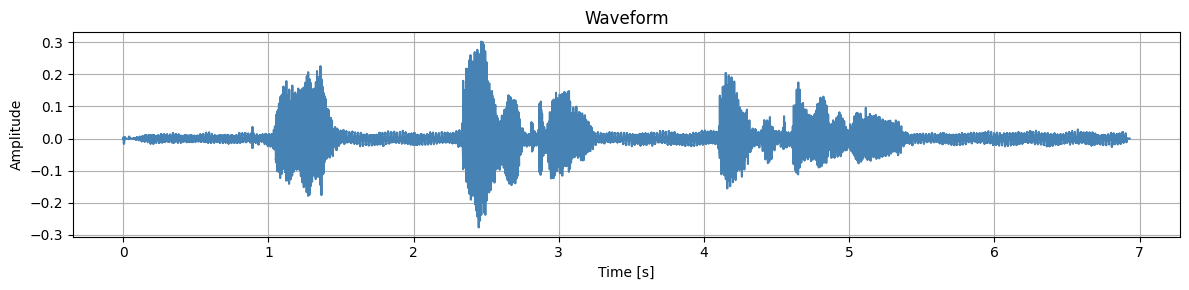

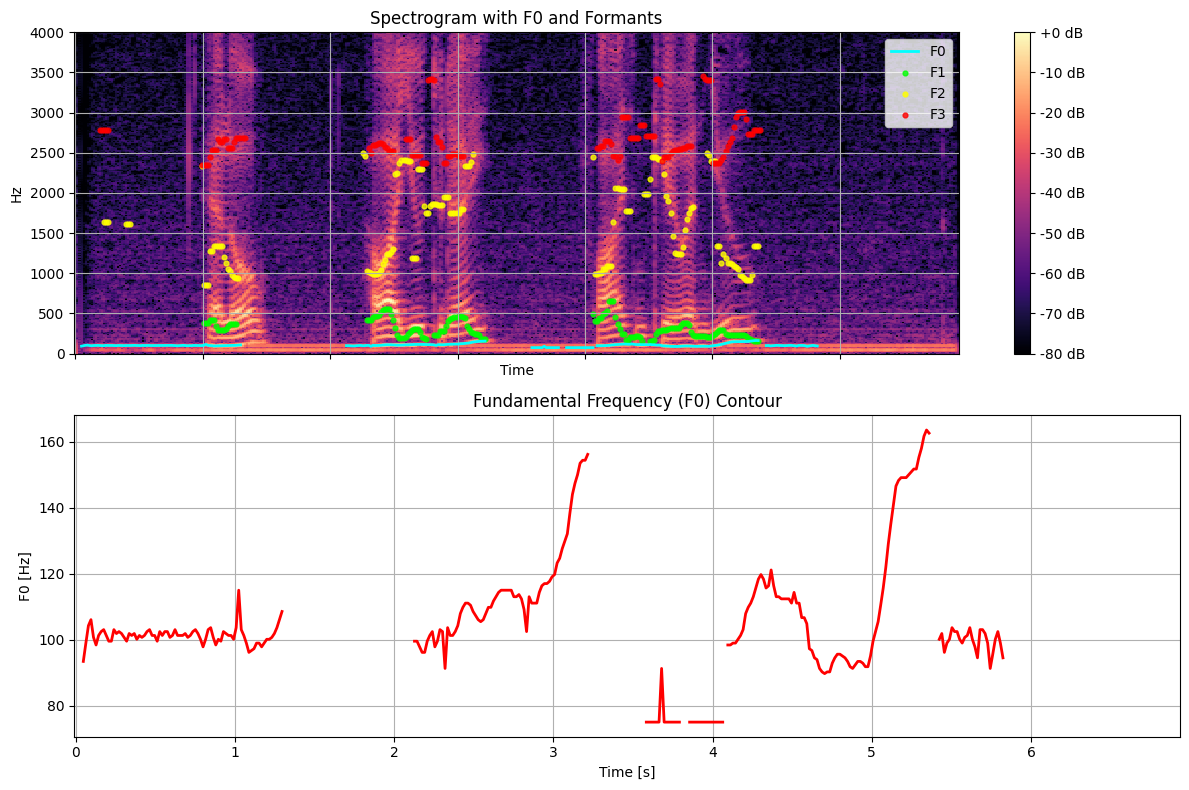

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import medfilt

min_len = min(len(f0_hz), len(F1), len(F2), len(F3), len(pitch_times))

f0_hz = f0_hz[:min_len]
pitch_times = pitch_times[:min_len]

F1 = F1[:min_len]
F2 = F2[:min_len]
F3 = F3[:min_len]

# -----------------------------
# Time axis for waveform
# -----------------------------
t = np.linspace(0, duration, num=len(signal))

# -----------------------------
# Prepare formant visualization
# -----------------------------

# Only keep formants where F0 exists (voiced regions)
F1_plot = np.where(~np.isnan(f0_hz), F1, np.nan)
F2_plot = np.where(~np.isnan(f0_hz), F2, np.nan)
F3_plot = np.where(~np.isnan(f0_hz), F3, np.nan)

# Smooth formants
F1_plot = medfilt(F1_plot, 5)
F2_plot = medfilt(F2_plot, 5)
F3_plot = medfilt(F3_plot, 5)

# Optional: remove unrealistic values
F1_plot[(F1_plot < 150) | (F1_plot > 900)] = np.nan
F2_plot[(F2_plot < 500) | (F2_plot > 2500)] = np.nan
F3_plot[(F3_plot < 1500) | (F3_plot > 3500)] = np.nan

# -----------------------------
# 1) Waveform
# -----------------------------
plt.figure(figsize=(12, 3))

plt.plot(t, signal, color="steelblue")

plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform")

plt.tight_layout()
plt.show()

# -----------------------------
# 2) Spectrogram
# -----------------------------

S = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

img = librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    cmap="magma",
    ax=ax[0],
)

fig.colorbar(img, ax=ax[0], format="%+2.0f dB")

ax[0].set_title("Spectrogram with F0 and Formants")

# -----------------------------
# Overlay F0
# -----------------------------

ax[0].plot(
    pitch_times,
    f0_hz,
    color="cyan",
    linewidth=2,
    label="F0",
)

# -----------------------------
# Overlay formants
# -----------------------------

ax[0].scatter(
    pitch_times,
    F1_plot,
    color="lime",
    s=12,
    alpha=0.8,
    label="F1",
)

ax[0].scatter(
    pitch_times,
    F2_plot,
    color="yellow",
    s=12,
    alpha=0.8,
    label="F2",
)

ax[0].scatter(
    pitch_times,
    F3_plot,
    color="red",
    s=12,
    alpha=0.8,
    label="F3",
)

# Limit frequency to speech band
ax[0].set_ylim(0, 4000)

ax[0].legend(loc="upper right")

# -----------------------------
# 3) F0 contour only
# -----------------------------

ax[1].plot(
    pitch_times,
    f0_hz,
    color="red",
    linewidth=2,
)

ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("F0 [Hz]")
ax[1].set_title("Fundamental Frequency (F0) Contour")

plt.tight_layout()
plt.show()

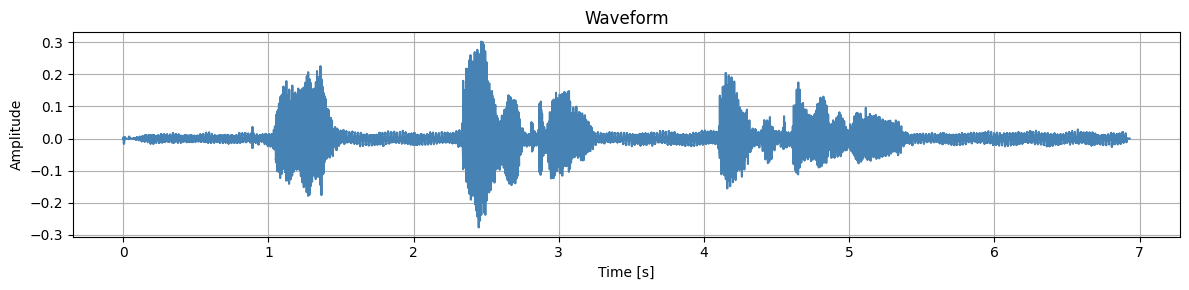

ValueError: x and y must have same first dimension, but have shapes (434,) and (430,)

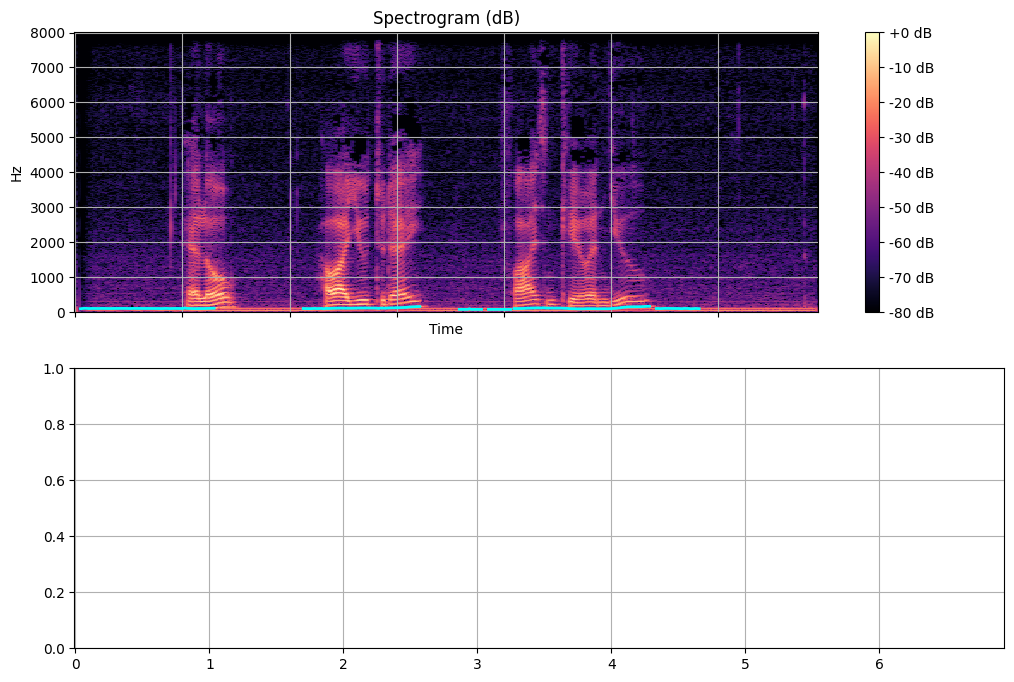

In [64]:
# Time axis for waveform
t = np.linspace(0, duration, num=len(signal))

# 1) Waveform
plt.figure(figsize=(12, 3))
plt.plot(t, signal, color="steelblue")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.tight_layout()
plt.show()

# 2) Spectrogram (STFT)
S = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Spectrogram
img = librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    cmap="magma",
    ax=ax[0],
)
fig.colorbar(img, ax=ax[0], format="%+2.0f dB")
ax[0].set_title("Spectrogram (dB)")

# F0 contour over spectrogram
ax[0].plot(pitch_times, f0_hz, color="cyan", linewidth=2, label="F0")

# Formant tracks over spectrogram
ax[0].plot(pitch_times, F1, color="lime", linewidth=1.5, label="F1")
ax[0].plot(pitch_times, F2, color="yellow", linewidth=1.5, label="F2")
ax[0].plot(pitch_times, F3, color="red", linewidth=1.5, label="F3")

ax[0].legend(loc="upper right")

# 3) F0-only contour for clarity
ax[1].plot(pitch_times, f0_hz, color="red")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("F0 [Hz]")
ax[1].set_title("Fundamental Frequency (F0) Contour")

plt.tight_layout()
plt.show()

## 6. Biểu đồ riêng cho F0 và các formant

Để dễ quan sát, ta tách thành 2 biểu đồ:
- Biểu đồ trên: chỉ F0 theo thời gian.
- Biểu đồ dưới: chỉ các formant F1, F2, F3 theo thời gian trong dải tần thoại điển hình.

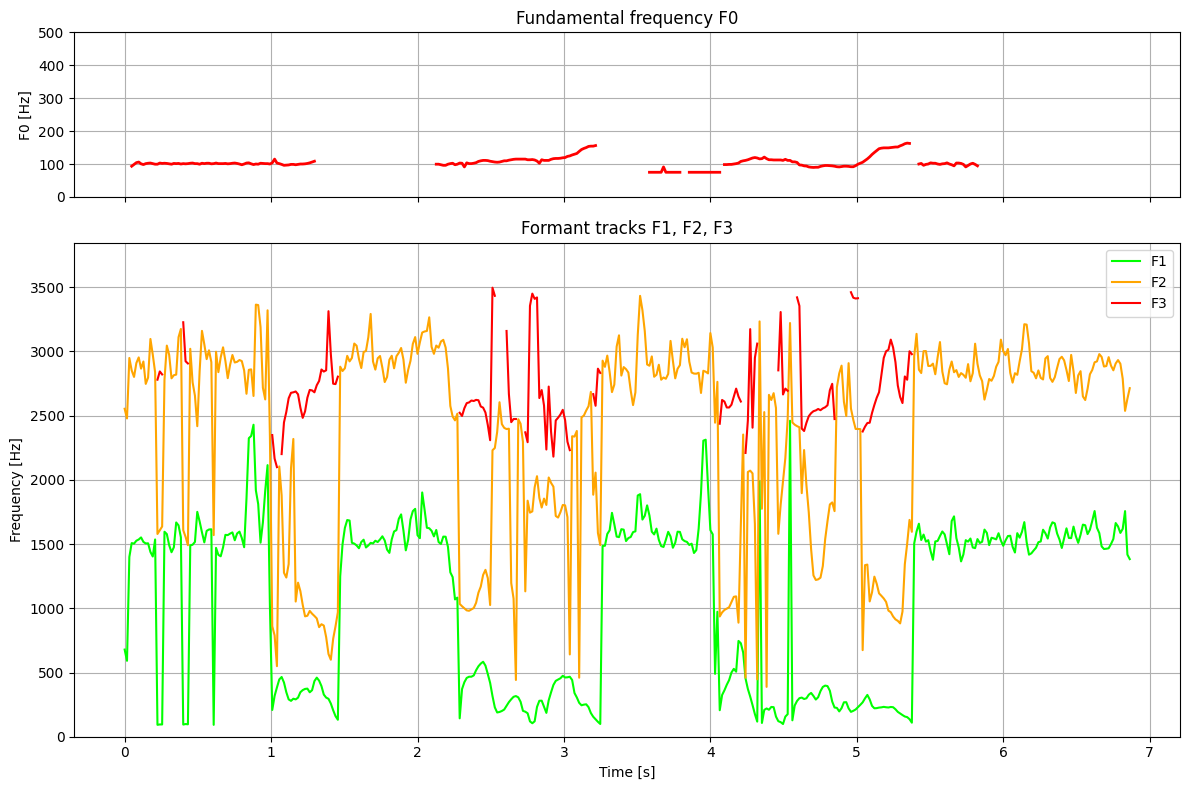

In [70]:
# Biểu đồ riêng F0 (trên) và formant (dưới)

# Tăng chiều cao hình và ưu tiên chiều cao cho biểu đồ formant
fig, (ax_f0, ax_formant) = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]},  # formant cao gấp 3 lần F0
)

# 1) F0
ax_f0.plot(pitch_times, f0_hz, color="red", linewidth=2)
ax_f0.set_ylabel("F0 [Hz]")
ax_f0.set_title("Fundamental frequency F0")
if np.isfinite(np.nanmax(f0_hz)):
    ax_f0.set_ylim(0, max(500, np.nanmax(f0_hz) * 1.1))

# 2) Formants
ax_formant.plot(pitch_times, F1, color="lime", linewidth=1.5, label="F1")
ax_formant.plot(pitch_times, F2, color="orange", linewidth=1.5, label="F2")
ax_formant.plot(pitch_times, F3, color="red", linewidth=1.5, label="F3")
ax_formant.set_xlabel("Time [s]")
ax_formant.set_ylabel("Frequency [Hz]")
ax_formant.set_title("Formant tracks F1, F2, F3")

all_formants = np.array([F1, F2, F3])

if np.all(np.isnan(all_formants)):
    ax_formant.set_ylim(0, 3500)
else:
    max_formant = np.nanmax(all_formants)
    ax_formant.set_ylim(0, max(3500, max_formant * 1.1))

ax_formant.legend(loc="upper right")
plt.tight_layout()
plt.show()

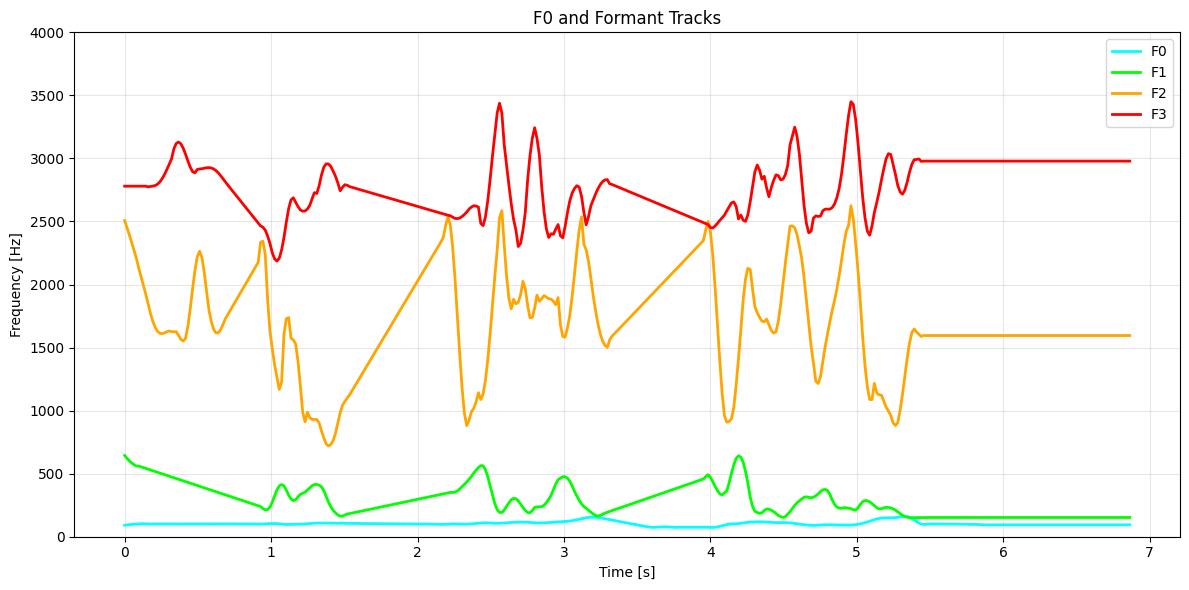

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------
# 1. Align length
# ------------------------------------------------

min_len = min(len(pitch_times), len(f0_hz), len(F1), len(F2), len(F3))

pitch_times = pitch_times[:min_len]
f0_hz = f0_hz[:min_len]
F1 = F1[:min_len]
F2 = F2[:min_len]
F3 = F3[:min_len]

# ------------------------------------------------
# 2. Remove unrealistic formants
# ------------------------------------------------

F1[(F1 < 150) | (F1 > 900)] = np.nan
F2[(F2 < 500) | (F2 > 2500)] = np.nan
F3[(F3 < 1500) | (F3 > 3500)] = np.nan


# ------------------------------------------------
# 3. Function: interpolate NaN
# ------------------------------------------------

def interpolate_nan(x):

    x = x.copy()

    nans = np.isnan(x)
    not_nans = ~nans

    if np.sum(not_nans) > 1:
        x[nans] = np.interp(
            np.flatnonzero(nans),
            np.flatnonzero(not_nans),
            x[not_nans],
        )

    return x


# ------------------------------------------------
# 4. Interpolate signals
# ------------------------------------------------

f0_interp = interpolate_nan(f0_hz)
F1_interp = interpolate_nan(F1)
F2_interp = interpolate_nan(F2)
F3_interp = interpolate_nan(F3)

# ------------------------------------------------
# 5. Smooth signals
# ------------------------------------------------

window = 11   # must be odd

f0_smooth = savgol_filter(f0_interp, window, 2)
F1_smooth = savgol_filter(F1_interp, window, 2)
F2_smooth = savgol_filter(F2_interp, window, 2)
F3_smooth = savgol_filter(F3_interp, window, 2)

# ------------------------------------------------
# 6. Plot
# ------------------------------------------------

plt.figure(figsize=(12,6))

# F0
plt.plot(
    pitch_times,
    f0_smooth,
    color="cyan",
    linewidth=2,
    label="F0"
)

# Formants
plt.plot(
    pitch_times,
    F1_smooth,
    color="lime",
    linewidth=2,
    label="F1"
)

plt.plot(
    pitch_times,
    F2_smooth,
    color="orange",
    linewidth=2,
    label="F2"
)

plt.plot(
    pitch_times,
    F3_smooth,
    color="red",
    linewidth=2,
    label="F3"
)

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("F0 and Formant Tracks")

plt.ylim(0, 4000)

plt.legend(loc="upper right")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()